# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [69]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [112]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\exp3000\exp3300_LP30_10C"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [113]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

#### Provide the directory for saving results

In [114]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\exp1000\00_LP30_pristine"

### Read the directory and extract values from images
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [115]:
stack_dict = read_saved_dict (src_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  2.66it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [116]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 4)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [117]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
#ROIs_02_pos00 = [[111, 92, 329, 82], [97, 73, 78, 378], [95, 342, 353, 78], [346, 83, 75, 356]]
#ROIs_04_pos01 = [[111, 92, 329, 82], [97, 73, 78, 321], [95, 342, 353, 65], [346, 83, 75, 313]]
#ROIs_06_pos02 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 83, 84, 321]]
#ROIs_08_pos03 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 83, 84, 321]]
#ROIs_10_pos04 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 83, 84, 321]]

# degrad LP30
#ROIs_04_pos01 = [[111, 92, 329, 82], [97, 73, 78, 312], [95, 342, 353, 52], [346, 83, 75, 308]]
#ROIs_06_pos02 = [[83, 92, 347, 82], [97, 73, 78, 213], [286, 327, 172, 86], [339, 83, 84, 321]]
#ROIs_08_pos03 = [[333, 33, 102, 95], [97, 106, 78, 345], [84, 337, 353, 66], [346, 273, 75, 187]]
#ROIs_10_pos04 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 213, 75, 267]]

# from each chip region LP30 pristine
#ROIs_02_pos00 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]
#ROIs_04_pos01 = [[292, 66, 160, 149], [64, 66, 160, 149], [64, 300, 160, 110], [294, 299, 160, 110]]
#ROIs_06_pos02 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]
#ROIs_08_pos03 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]
ROIs_10_pos04 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]

In [97]:
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray')

IndexError: list index out of range

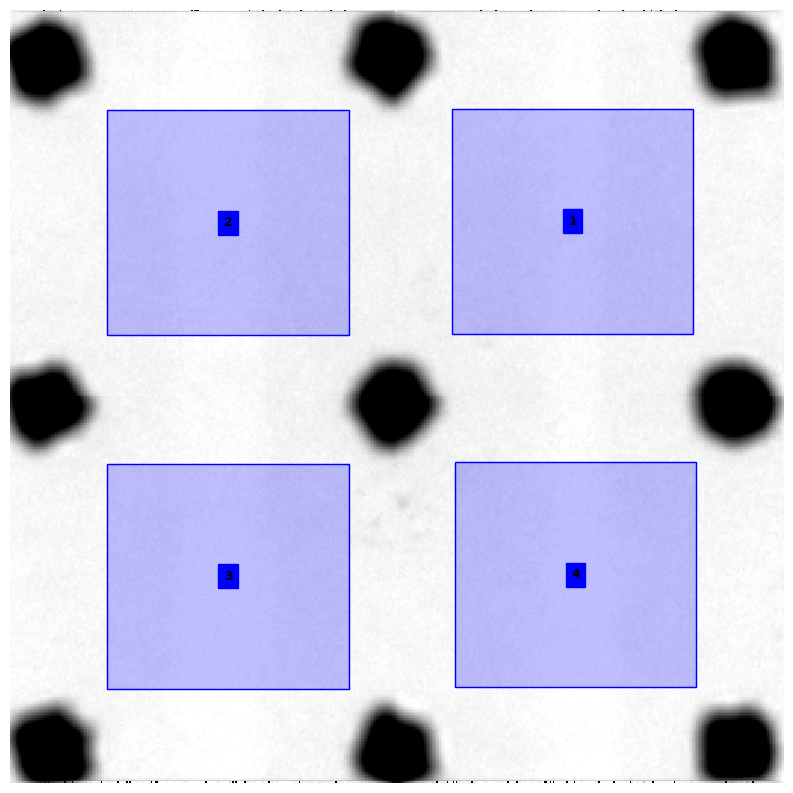

In [118]:
show_img(avg_imgs[0], dr = [(ROIs_10_pos04, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [119]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [120]:
table_val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 10, 
                                 flight_path = 56.5, start_slice = 0, end_slice=80, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [121]:
table_val_rois = table_val_rois.loc[0:76, table_val_rois.columns != 'Wavelength [Å]']
table_val_rois = table_val_rois.reset_index(drop=True)
table_val_rois

,Values_02_pos00_roi_1,Values_02_pos00_roi_2,Values_02_pos00_roi_3,Values_02_pos00_roi_4
0,-0.000260,-0.000082,-0.000190,-0.000228
1,-0.000175,-0.000007,-0.000158,-0.000155
2,0.000199,0.000351,0.000305,0.000202
3,0.016631,0.017910,0.018010,0.016674
4,0.062591,0.065530,0.064672,0.061823
5,0.123855,0.128385,0.127834,0.122720
6,0.201761,0.209334,0.209506,0.201727
7,0.288173,0.299785,0.295300,0.284457
8,0.413486,0.429990,0.423256,0.407464
9,0.649967,0.669427,0.670964,0.649272


### H cross section parameters

In [ ]:
thickness = 0.0585
#h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
#lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': thickness}

## exp1000 -> LP30


In [ ]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [ ]:
requested_cs = ['h_cs']
cs_table = get_cross_sections (table_val_rois, compounds_dict, requested_cs, dst_dir = src_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')

In [ ]:
cs_table

In [ ]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[3:76, ['target wvl','target cs LP30', 'target cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot(x='Wavelength [Å]', y=['CS_H_in_LP30_Values_02_pos00_roi_1', 'CS_H_in_LP30_Values_04_pos01_roi_4'])
cs_ref_data.plot(ax = ax, x='target wvl', y=['target cs LP30'], 
                 grid = True, fontsize = 12)

plt.suptitle('H CS in LP30 CustomCells', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

### Normalize by 3A

In [ ]:
cs_table_norm3A = normalize_3A (cs_table)

In [ ]:
cs_ref_norm3A = normalize_3A (cs_ref_data, 'target wvl')

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table_norm3A.plot(x='Wavelength [Å]', y=['CS_H_in_LP30_Values_02_pos00_roi_1', 'CS_H_in_LP30_Values_04_pos01_roi_4'])
cs_ref_norm3A.plot(ax = ax, x='target wvl', y=['target cs LP30'], 
                 grid = True, fontsize = 12)

plt.suptitle('H CS in LP30 CustomCells', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("Normalized H cross-section [-]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None )
cs_table_norm3A

### Normalize by PE and 3A
The values listed are interpolated to match the wavelength of the experiment CS

In [ ]:
PE_list_vals = cs_ref_norm3A['target cs PE']. to_list()
cs_table_norm3A_PE = normalize_3A_PE (cs_table_norm3A, PE_list_vals)
cs_ref_norm3A_PE = normalize_3A_PE (cs_ref_norm3A, PE_list_vals, 'target wvl')
cs_table_norm3A_PE

In [ ]:
cs_ref_norm3A_PE

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table_norm3A_PE.plot(x='Wavelength [Å]', y=['CS_H_in_LP30_Values_02_pos00_roi_1', 'CS_H_in_LP30_Values_04_pos01_roi_4'])
cs_ref_norm3A_PE.plot(ax = ax, x='target wvl', y=['target cs LP30'], 
                 grid = True, fontsize = 12)

plt.suptitle('H CS in LP30 CustomCells', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("Normalized H cross-section [-]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()